# Bank Churn

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import math
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler , LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier ,VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [15]:
df = pd.read_csv(r"C:\Users\G16\Downloads\archive\train.csv")

In [16]:
df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165029,165029,15667085,Meng,667,Spain,Female,33.0,2,0.00,1,1.0,1.0,131834.75,0
165030,165030,15665521,Okechukwu,792,France,Male,35.0,3,0.00,1,0.0,0.0,131834.45,0
165031,165031,15664752,Hsia,565,France,Male,31.0,5,0.00,1,1.0,1.0,127429.56,0
165032,165032,15689614,Hsiung,554,Spain,Female,30.0,7,161533.00,1,0.0,1.0,71173.03,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [18]:
df.isna().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

##  NO NULL FOUND 

## Columns [  Surname   ,       Geography    ,     Gender    ] are object type

In [19]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [20]:
df2 = df[["id" , "CustomerId" , "Exited"]]

In [21]:
correlation_matrix = df2.corr()

<Axes: >

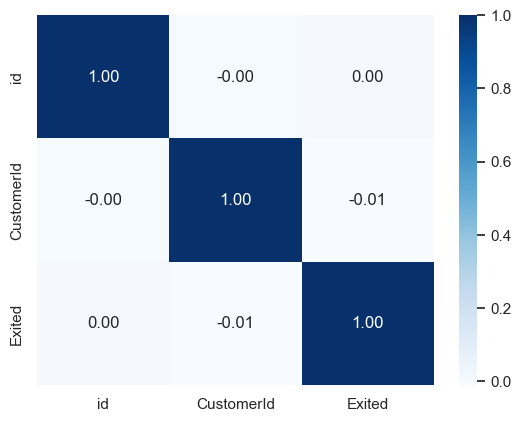

In [22]:
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')

<Axes: >

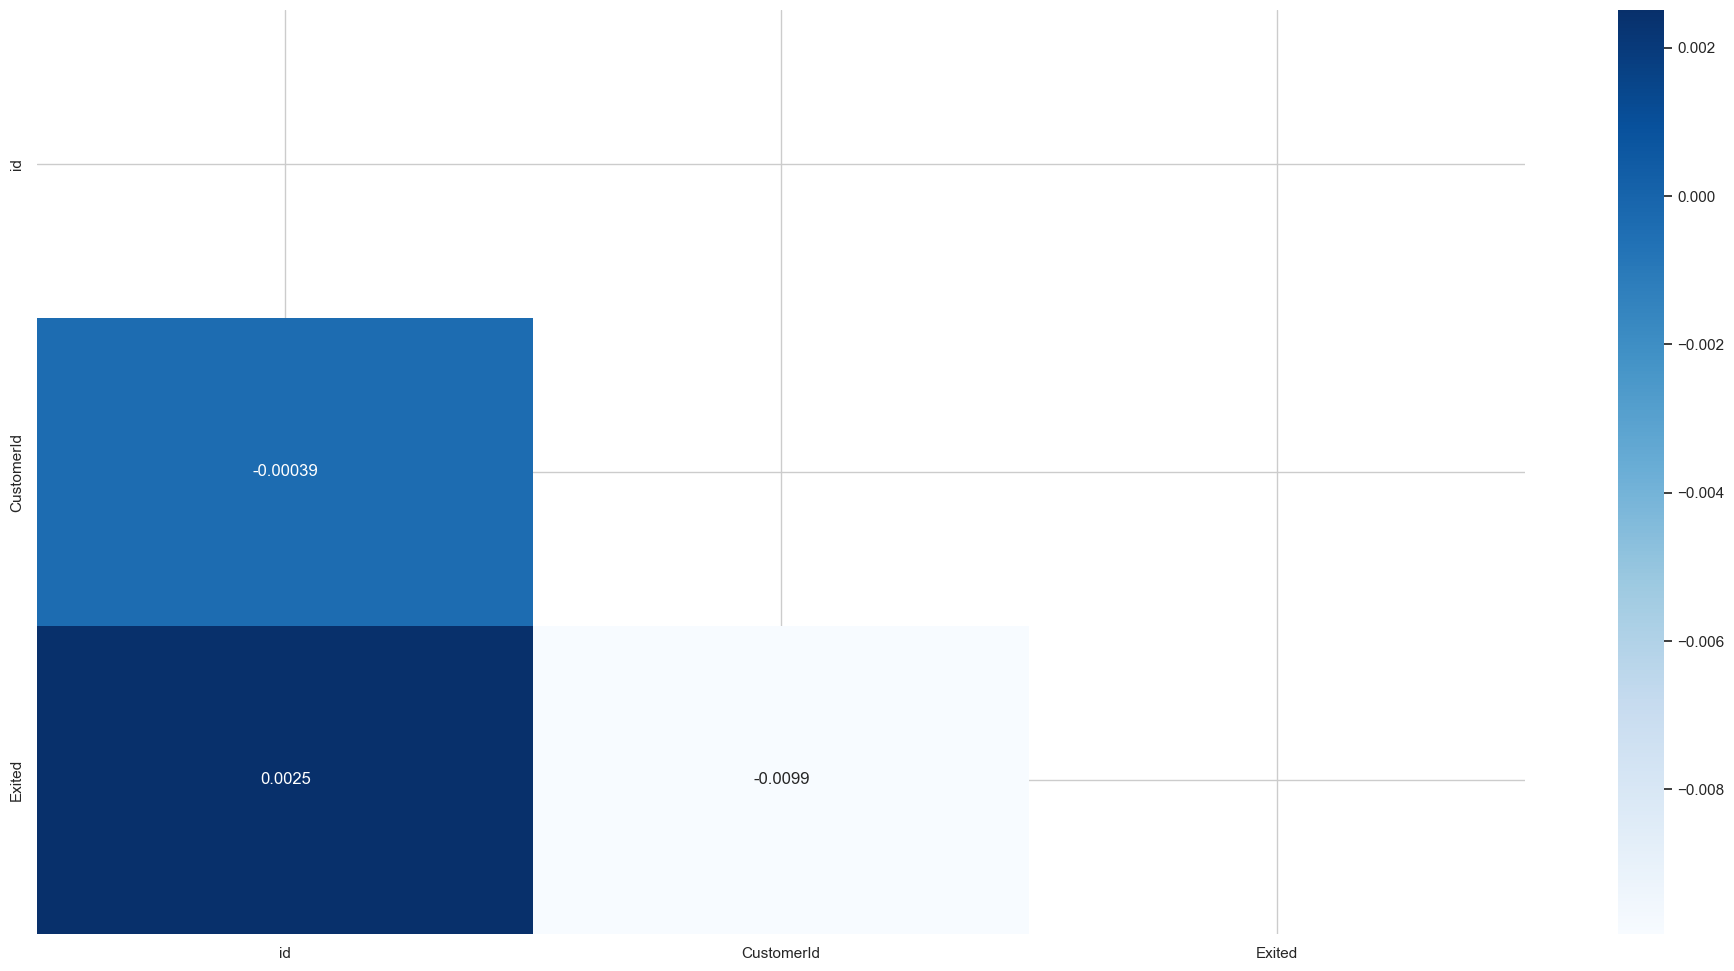

In [23]:
plt.figure(figsize=(24,12))
sns.heatmap(correlation_matrix,annot=True,cmap="Blues",mask=np.triu(np.ones_like(correlation_matrix, dtype=bool)))

### [Surname , id , CustomerId] is not affecting to target so drop them

In [24]:
df.drop(columns=["Surname" , "id" , "CustomerId" ] , inplace=True)

In [25]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...
165029,667,Spain,Female,33.0,2,0.00,1,1.0,1.0,131834.75,0
165030,792,France,Male,35.0,3,0.00,1,0.0,0.0,131834.45,0
165031,565,France,Male,31.0,5,0.00,1,1.0,1.0,127429.56,0
165032,554,Spain,Female,30.0,7,161533.00,1,0.0,1.0,71173.03,0


<Axes: xlabel='Geography', ylabel='count'>

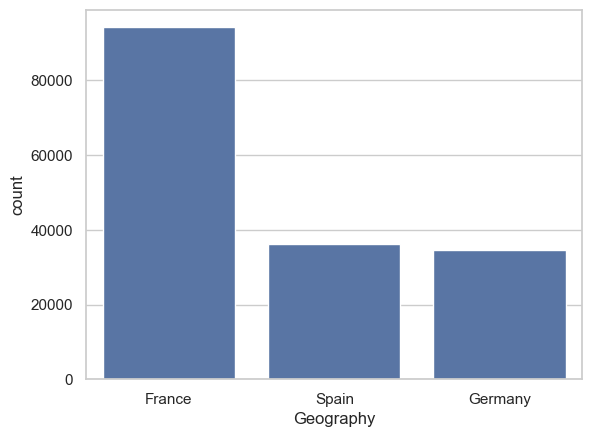

In [26]:
sns.countplot(data=df , x="Geography")

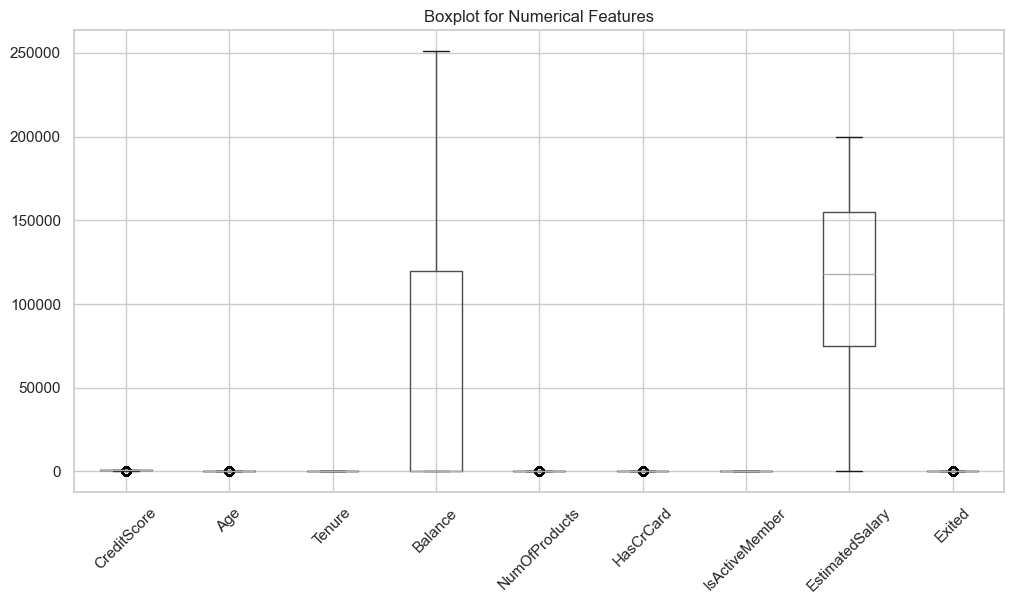

In [27]:
df.boxplot(figsize=(12,6), rot=45)
plt.title("Boxplot for Numerical Features")
plt.show()

# Encoding Object Columns

In [28]:
# df  = pd.get_dummies(df , columns=["Gender" , "Geography"] , drop_first=True , dtype=int )

In [29]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,668,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0,0,0
1,627,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0,0,0
2,678,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0,0,0
3,581,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,0
4,716,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0,0,1


In [30]:
gender_encoder = LabelEncoder()

df['Gender'] = gender_encoder.fit_transform(df['Gender'])
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,668,1,33.0,3,0.00,2,1.0,0.0,181449.97,0,0,0
1,627,1,33.0,1,0.00,2,1.0,1.0,49503.50,0,0,0
2,678,1,40.0,10,0.00,2,1.0,0.0,184866.69,0,0,0
3,581,1,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,0
4,716,1,33.0,5,0.00,2,1.0,1.0,15068.83,0,0,1


In [31]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,668,1,33.0,3,0.00,2,1.0,0.0,181449.97,0,0,0
1,627,1,33.0,1,0.00,2,1.0,1.0,49503.50,0,0,0
2,678,1,40.0,10,0.00,2,1.0,0.0,184866.69,0,0,0
3,581,1,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,0
4,716,1,33.0,5,0.00,2,1.0,1.0,15068.83,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
165029,667,0,33.0,2,0.00,1,1.0,1.0,131834.75,0,0,1
165030,792,1,35.0,3,0.00,1,0.0,0.0,131834.45,0,0,0
165031,565,1,31.0,5,0.00,1,1.0,1.0,127429.56,0,0,0
165032,554,0,30.0,7,161533.00,1,0.0,1.0,71173.03,0,0,1


## Visiualization

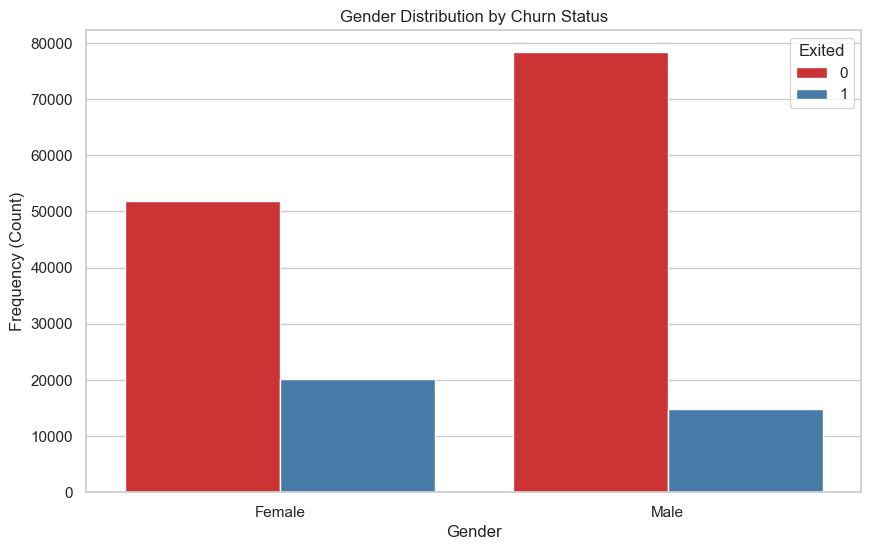

In [32]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender', hue='Exited', palette='Set1')
plt.title('Gender Distribution by Churn Status')
plt.xlabel('Gender')
plt.ylabel('Frequency (Count)')
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()

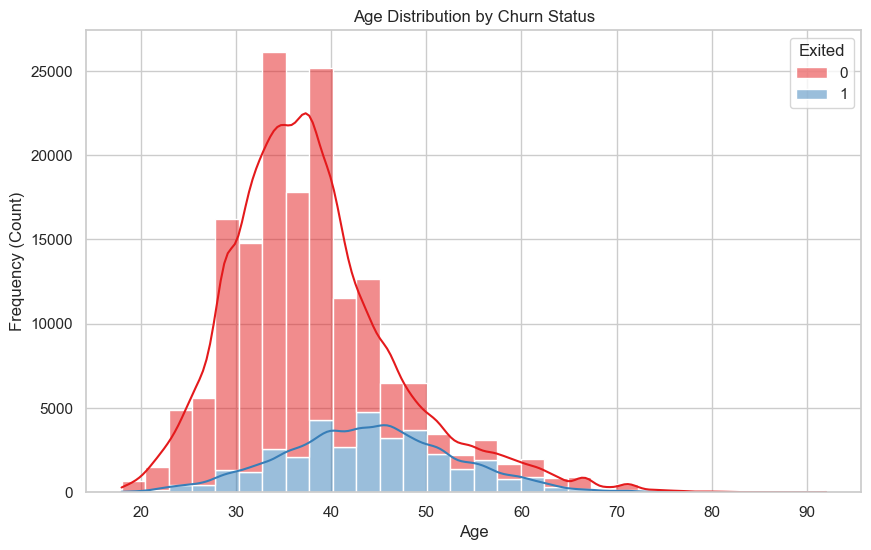

In [33]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True, palette='Set1', multiple='stack')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Frequency (Count)')

plt.show()

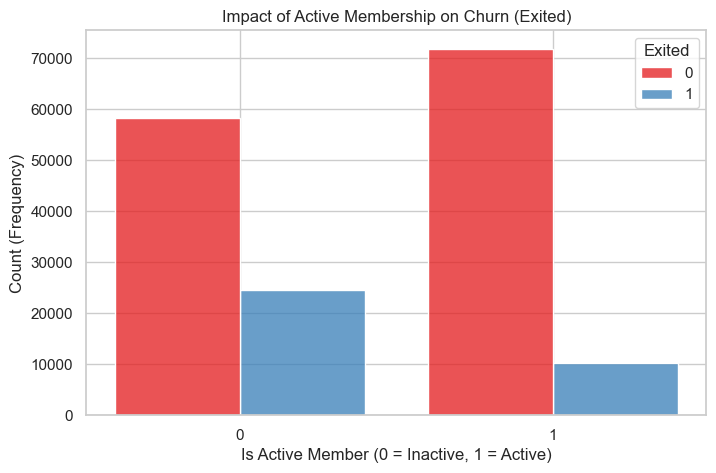

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='IsActiveMember', hue='Exited', multiple='dodge', shrink=0.8, discrete=True, palette='Set1')

plt.title('Impact of Active Membership on Churn (Exited)')
plt.xlabel('Is Active Member (0 = Inactive, 1 = Active)')
plt.ylabel('Count (Frequency)')
plt.xticks([0, 1]) 
plt.show()

In [35]:
correlation_matrix = df.corr()

<Axes: >

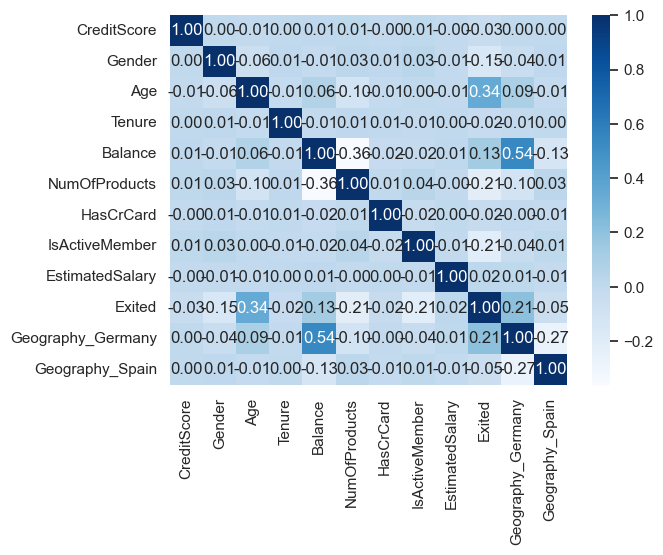

In [36]:
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')

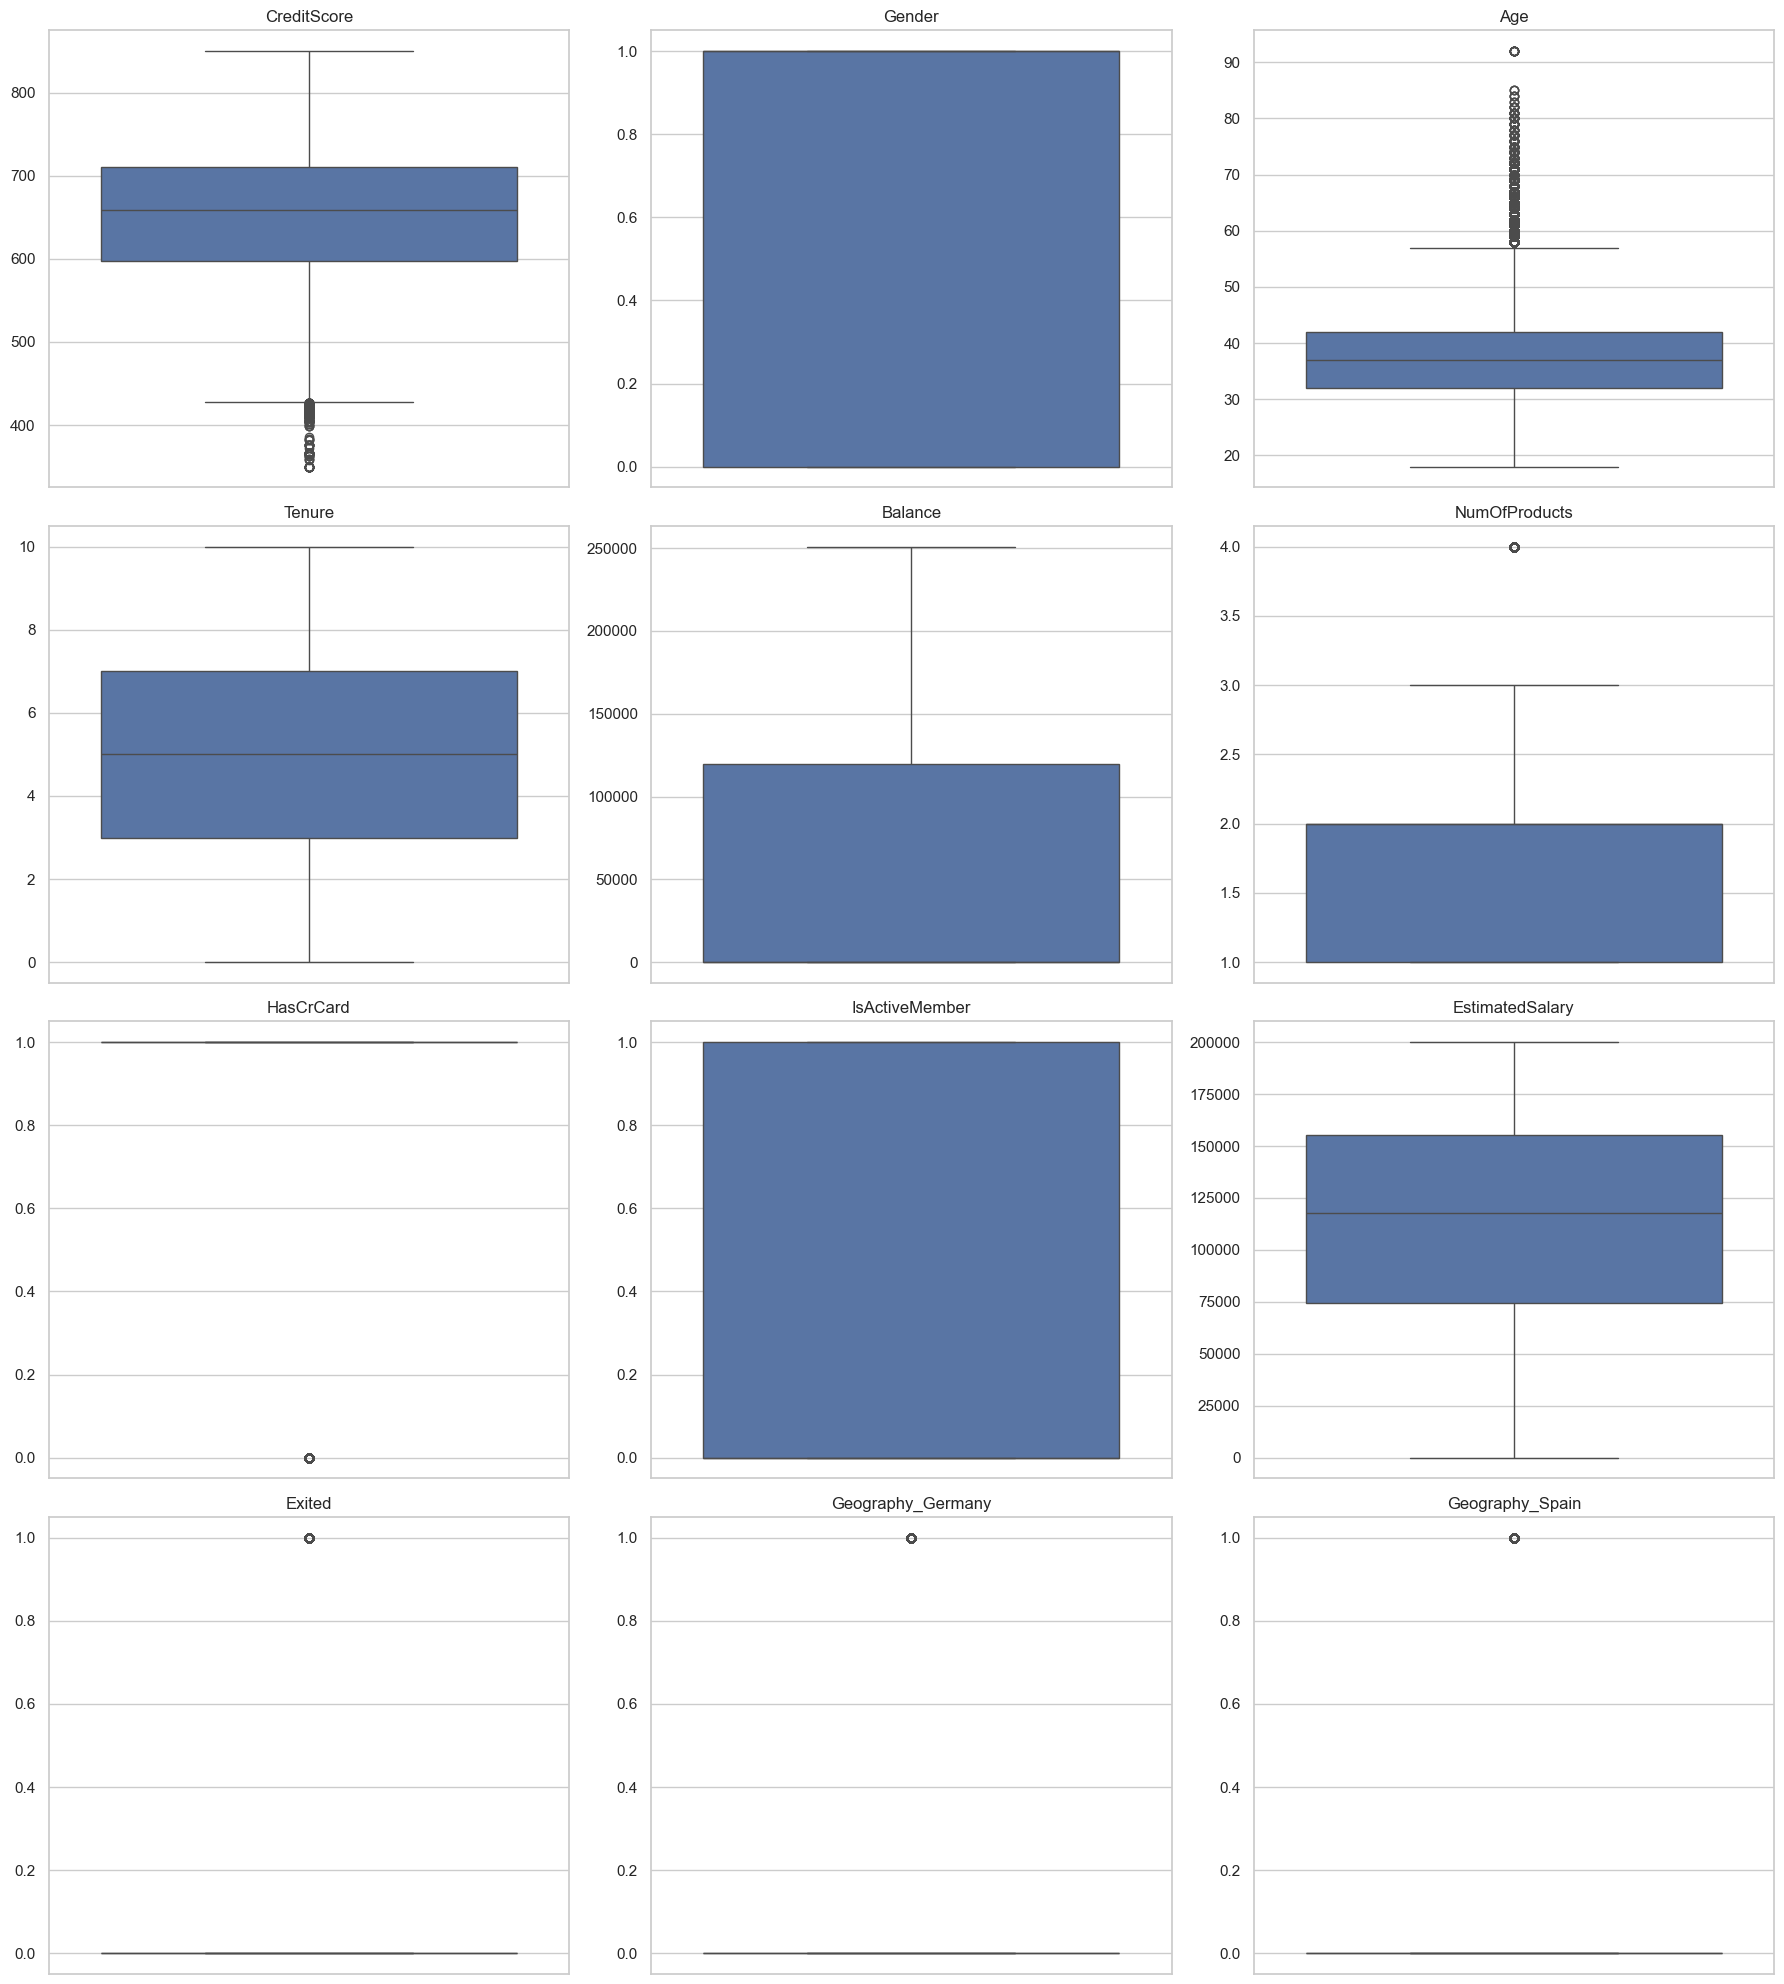

In [37]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include='number').columns

# Number of columns in the grid
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Draw one boxplot for each feature
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Drop CreditScore outliers

In [38]:

cols_cap = ['CreditScore', 'Age', 'NumOfProducts']

for col in cols_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    


In [39]:
for col in cols_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"The number of outliers in column {col} is now: {len(outliers)}")

The number of outliers in column CreditScore is now: 0
The number of outliers in column Age is now: 0
The number of outliers in column NumOfProducts is now: 0


## Scaling (Normalization)

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Separate features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [41]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy=0.7, random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [43]:
# from imblearn.under_sampling import RandomUnderSampler

# rus = RandomUnderSampler(random_state=42)

# X_train, y_train = rus.fit_resample(
#     X_train,
#     y_train
# )

<Axes: xlabel='Exited', ylabel='count'>

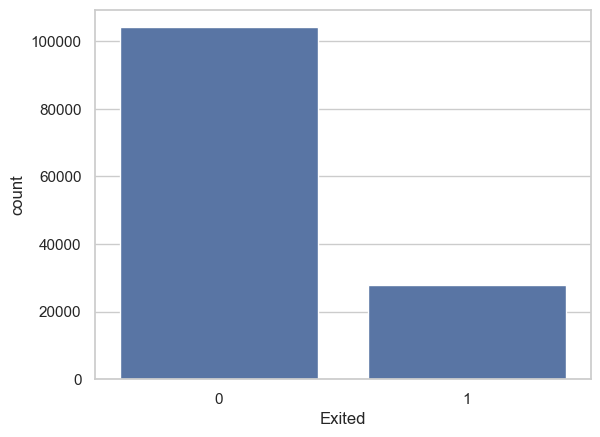

In [44]:
sns.countplot(x=y_train)

# Train models

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

weights_to_try = [1.0, 1.3, 1.5, 1.7, 2.0 , 2.3 , 2.5]

results = []

print("Running fast tests... ⏳")

for w in weights_to_try:
    test_model = XGBClassifier(
        n_estimators=250,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.6,
        colsample_bytree=0.8,
        scale_pos_weight=w,  
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
    
    test_model.fit(X_train_resampled, y_train_resampled)
    y_pred_test = test_model.predict(X_test_scaled)
    
    p = precision_score(y_test, y_pred_test)
    r = recall_score(y_test, y_pred_test)
    f = f1_score(y_test, y_pred_test)
    
    results.append({
        'scale_pos_weight': w,
        'Precision ': round(p, 3),
        'Recall ': round(r, 3),
        'F1-Score': round(f, 3)
    })

results_df = pd.DataFrame(results)
print("\n--- Comparison Table ---")
display(results_df)

Running fast tests... ⏳

--- Comparison Table ---


,scale_pos_weight,Precision,Recall,F1-Score
0,1.0,0.710,0.598,0.649
1,1.3,0.672,0.644,0.658
2,1.5,0.650,0.670,0.660
3,1.7,0.633,0.689,0.660
4,2.0,0.606,0.720,0.658
5,2.3,0.589,0.741,0.656
6,2.5,0.573,0.756,0.652


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import numpy as np
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

X_t, X_val, y_t, y_val = train_test_split(
    X_train_scaled, y_train, 
    test_size=0.2, random_state=42, stratify=y_train
)

smote = SMOTE(sampling_strategy=0.8, random_state=42)
X_t_resampled, y_t_resampled = smote.fit_resample(X_t, y_t)

print("Training model for Threshold Tuning... ⏳")
xgb_tuned = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    scale_pos_weight=1.5, 
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_tuned.fit(X_t_resampled, y_t_resampled)

y_val_probs = xgb_tuned.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.3, 0.7, 0.02) # هنجرب من 0.30 لحد 0.70
best_thresh = 0.5
best_f1 = 0

for thresh in thresholds:
    y_val_pred = (y_val_probs >= thresh).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\n✅ Best Threshold Found on Validation Data: {best_thresh:.2f}")
print(f"Validation F1-Score: {best_f1:.3f}")

y_test_probs = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

y_test_pred_final = (y_test_probs >= best_thresh).astype(int)

print("\n--- Final Classification Report on Test Set ---")
print(classification_report(y_test, y_test_pred_final))

Training model for Threshold Tuning... ⏳

✅ Best Threshold Found on Validation Data: 0.50
Validation F1-Score: 0.662

--- Final Classification Report on Test Set ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     26023
           1       0.64      0.68      0.66      6984

    accuracy                           0.85     33007
   macro avg       0.78      0.79      0.78     33007
weighted avg       0.85      0.85      0.85     33007



In [48]:
fast_xgb_model = XGBClassifier(
    n_estimators=250,        
    max_depth=8,              
    learning_rate=0.05,       
    subsample=0.6,            
    colsample_bytree=0.8,     
    
    scale_pos_weight=3,    
    
    random_state=42,
    eval_metric='logloss'
)

print("Training the fast model... ⏳")
fast_xgb_model.fit(X_train_resampled, y_train_resampled)


y_pred_fast = fast_xgb_model.predict(X_test_scaled)

print("\n--- Fast Model Results ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_fast))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_fast))

Training the fast model... ⏳

--- Fast Model Results ---
Confusion Matrix:
[[21498  4525]
 [ 1525  5459]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88     26023
           1       0.55      0.78      0.64      6984

    accuracy                           0.82     33007
   macro avg       0.74      0.80      0.76     33007
weighted avg       0.85      0.82      0.83     33007



In [50]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)

param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': ['balanced'] 
}

grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("Training Logistic Regression... ⏳")
grid_lr.fit(X_train_resampled, y_train_resampled)

best_lr = grid_lr.best_estimator_
print("\nBest Parameters for LR:", grid_lr.best_params_)

y_pred_lr = best_lr.predict(X_test_scaled)

print("\n--- Logistic Regression Results ---")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Training Logistic Regression... ⏳

Best Parameters for LR: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'lbfgs'}

--- Logistic Regression Results ---
[[19803  6220]
 [ 1847  5137]]
              precision    recall  f1-score   support

           0       0.91      0.76      0.83     26023
           1       0.45      0.74      0.56      6984

    accuracy                           0.76     33007
   macro avg       0.68      0.75      0.70     33007
weighted avg       0.82      0.76      0.77     33007



In [49]:

rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', 'balanced_subsample'] # تعديل البشمهندسة
}

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',  
    n_jobs=-1
)

print("Training Random Forest... ⏳")
grid_rf.fit(X_train_resampled, y_train_resampled) 

best_rf = grid_rf.best_estimator_
print("\nBest Parameters for RF:", grid_rf.best_params_)

y_pred_rf = best_rf.predict(X_test_scaled)

print("\n--- Random Forest Results ---")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Training Random Forest... ⏳

Best Parameters for RF: {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

--- Random Forest Results ---
[[23905  2118]
 [ 2796  4188]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     26023
           1       0.66      0.60      0.63      6984

    accuracy                           0.85     33007
   macro avg       0.78      0.76      0.77     33007
weighted avg       0.85      0.85      0.85     33007



In [52]:
X_t, X_val, y_t, y_val = train_test_split(
    X_train_scaled, y_train, 
    test_size=0.2, random_state=42, stratify=y_train
)

smote = SMOTE(sampling_strategy=0.8, random_state=42)
X_t_resampled, y_t_resampled = smote.fit_resample(X_t, y_t)

print("Training model for Threshold Tuning... ⏳")
xgb_tuned = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    scale_pos_weight=1.5, 
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_tuned.fit(X_t_resampled, y_t_resampled)

y_val_probs = xgb_tuned.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.3, 0.7, 0.02) 
best_thresh = 0.5
best_f1 = 0

for thresh in thresholds:
    y_val_pred = (y_val_probs >= thresh).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    
    # حفظ أفضل Threshold
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\n✅ Best Threshold Found on Validation Data: {best_thresh:.2f}")
print(f"Validation F1-Score: {best_f1:.3f}")

y_test_probs = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

y_test_pred_final = (y_test_probs >= best_thresh).astype(int)

print("\n--- Final Classification Report on Test Set ---")
print(classification_report(y_test, y_test_pred_final))

Training model for Threshold Tuning... ⏳

✅ Best Threshold Found on Validation Data: 0.50
Validation F1-Score: 0.662

--- Final Classification Report on Test Set ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     26023
           1       0.64      0.68      0.66      6984

    accuracy                           0.85     33007
   macro avg       0.78      0.79      0.78     33007
weighted avg       0.85      0.85      0.85     33007



In [ ]:
# XGBoost model
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [200, 250],
    'max_depth': [5, 7, 8],
    'learning_rate': [0.01, 0.04, 0.05],
    'subsample': [0.4, 0.6, 0.8],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 1.5, 2]  
}

# Grid Search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',  
    n_jobs=-1
)

# Train
grid.fit(X_train_resampled, y_train_resampled)
# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test_scaled)
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 250, 'scale_pos_weight': 1.5, 'subsample': 0.6}
Accuracy: 0.8553943102978157

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     26023
           1       0.66      0.66      0.66      6984

    accuracy                           0.86     33007
   macro avg       0.78      0.78      0.78     33007
weighted avg       0.86      0.86      0.86     33007


Confusion Matrix:
[[23609  2414]
 [ 2359  4625]]


In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=2,
    class_weight='balanced',  # Crucial for imbalance
    random_state=42
)

# 2. Define XGBoost with your BEST parameters
xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric='logloss'
)

# 3. Create the Voting Classifier (voting='soft' averages the probabilities)
voting_clf = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],
    voting='soft'
)

# 4. Train the Ensemble Model
print("Training the Voting Classifier... This might take a minute ⏳")
# Note: Ensure you use your scaled data variables (e.g., X_train_scaled, y_train)
voting_clf.fit(X_train, y_train) 

# 5. Predict and Evaluate
y_pred_voting = voting_clf.predict(X_test)

print("\n--- Voting Classifier Results ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_voting))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))

Training the Voting Classifier... This might take a minute ⏳

--- Voting Classifier Results ---
Confusion Matrix:
[[24205  1779]
 [ 2808  4165]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     25984
           1       0.70      0.60      0.64      6973

    accuracy                           0.86     32957
   macro avg       0.80      0.76      0.78     32957
weighted avg       0.85      0.86      0.86     32957



In [ ]:
import joblib

joblib.dump(best_model, 'xgb_best_model.pkl')


print("Saved and active!")

Saved and active!
